created 31.03.2025
use the same functions as "illumination_correction_xxx.ipynb"
just try again as it was too messy
goal: test normalization 

transects (.h5):        desc:                                                                                               quality [1-10]      usage [1-10]    num. of clips
221                     pipe, bad shadowing, no bombs. treestem                                                             2                   3               5
520-from1               too short                                                                                           9                   1?              1
520-from3         *     first transect: use for classify dark spots, leafes, square rock, fish, ~3 bombs                    7                   6               3
057               *     generally even illu., 10+ bombs, good for classify bombs (but not dark spots)                       8                   9               5
639               *     last transect: useable, 10+ bombs, alt. oscillating (hard to classify?)                             7                   4               5
028               *     first transect: good separability (dark vs. sed.), no bombs, many dark spots, even illu.            8                   8               5
135                     even illu, few dark spots (not very distinct), no bombs                                             10                  2               2

ref. plate:
504                     looks useable, but short
648                     also usable, longer



In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
import illumination_functions as ilf

In [2]:
# 0.28, transect1 -> godt eksempel å teste korrigering av både along og transverse illu. correction. dark spots med bomber er veldig tydelig
filename = r"E:\mjosa\29\uhi_rad\rad_uhi_20241029_125028_1.h5"

with h5py.File(filename, "r") as h5file:
    data = h5file["processed/radiance/dataCube"][:]

    band_2_wavelength = h5file[
        "processed/radiance/calibration/spectral/band2Wavelength"
    ][:]

ilf.describe_data(data)

=== Data Overview ===
Shape of data: (1453, 968, 210) (tracks, slit_pixels, wavelengths)
 - Number of tracks (time steps): 1453
 - Number of slit pixels: 968
 - Number of wavelengths: 210
Global Intensity Range: 0.000 to 0.717


In [3]:
wvl_index = ilf.wvl_nm_to_index(wvl_nm=500, band_2_wavelength=band_2_wavelength)
print(f"first wvl_index = {wvl_index}")
wvl_index = ilf.wvl_nm_to_index(wvl_nm=690, band_2_wavelength=band_2_wavelength)
print(f"filastwvl_index = {wvl_index}\n")

# *adjustments:
wvl_start = 70
wvl_end = 177

# *data (shape): (n_tracks, n_slit_pixels, n_wavelengths)
# data = data[200:210, :, :]
data = data[500:600, :, wvl_start:wvl_end]

ilf.describe_data(data)

first wvl_index = 70
filastwvl_index = 177

=== Data Overview ===
Shape of data: (100, 968, 107) (tracks, slit_pixels, wavelengths)
 - Number of tracks (time steps): 100
 - Number of slit pixels: 968
 - Number of wavelengths: 107
Global Intensity Range: 0.033 to 0.621


# Normalization, tranverse direction as shown in heatmap

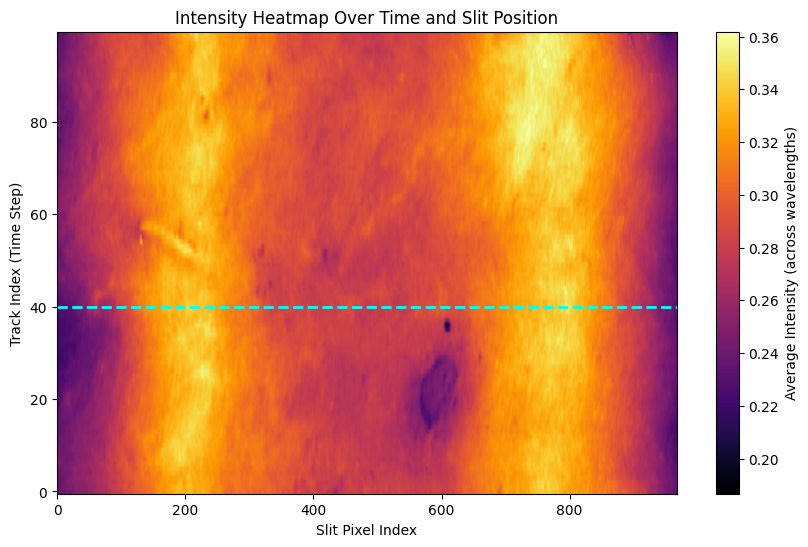

In [4]:
# checking how the headmap look slike. will first test for the highlighted trackindex
track_index = 40

ilf.plot_intensity_heatmap(data, temporal_index=track_index)

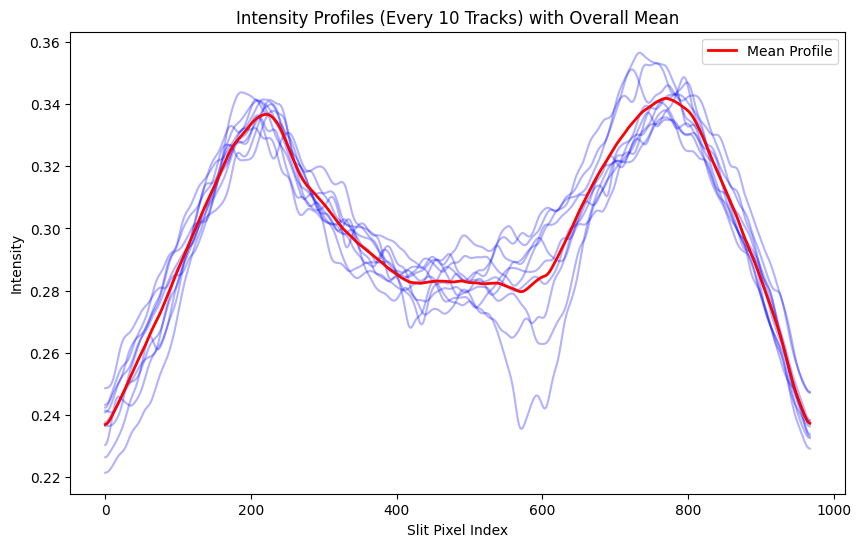

In [5]:
# show how the spectras look for different track_index before we do the correction
ilf.plot_mean_tracks(data, 10, sigma=5)

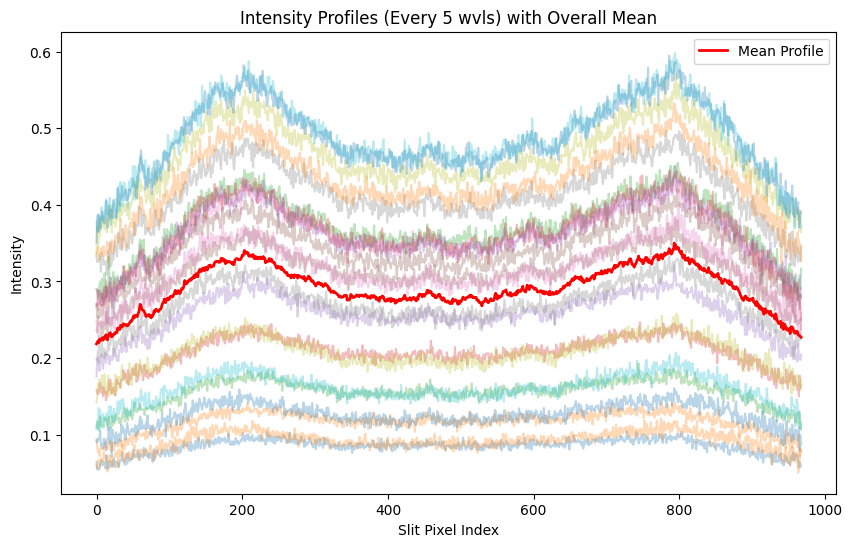

In [6]:
import numpy as np
import matplotlib.pyplot as plt


def plot_mean_wvls(data, track_index, skip_interval=5):
    wvl_profiles = data[track_index, :, ::skip_interval]

    plt.figure(figsize=(10, 6))

    # Plot each individual wavelength profile
    for i in range(wvl_profiles.shape[1]):
        plt.plot(
            wvl_profiles[:, i],
            alpha=0.3,
        )  # limit legend clutter

    # Compute and plot the mean profile
    mean_profile = np.mean(wvl_profiles, axis=1)
    plt.plot(mean_profile, color="red", linewidth=2, label="Mean Profile")

    plt.xlabel("Slit Pixel Index")
    plt.ylabel("Intensity")
    plt.title(f"Intensity Profiles (Every {skip_interval} wvls) with Overall Mean")
    plt.legend()
    plt.show()


plot_mean_wvls(data, track_index, skip_interval=5)

In [7]:
# def plot_normalized_wavelength_profiles(
#     data,
#     wavelengths,
#     track_index=0,
#     selected_wavelengths=None,
#     skip_interval=10,
#     sigma=5,
# ):
#     from scipy.ndimage import gaussian_filter1d
#     import numpy as np
#     import matplotlib.pyplot as plt

#     wvl_profiles = data[track_index, :, :]  # shape: (n_slit_pixels, n_wavelengths)
#     n_slit_pixels = wvl_profiles.shape[0]
#     x = np.arange(n_slit_pixels)

#     # Choose selected wavelengths if not provided
#     if selected_wavelengths is None:
#         min_wl, max_wl = 450, 700
#         selected_wavelengths = np.arange(np.ceil(min_wl / 75) * 75, max_wl, 75)

#     # Apply skip_interval within selected_wavelengths
#     selected_wavelengths = selected_wavelengths[::skip_interval]

#     plt.figure(figsize=(10, 6))
#     all_profiles = []

#     for wl in selected_wavelengths:
#         profile = np.array(
#             [
#                 np.interp(wl, wavelengths, wvl_profiles[i, :])
#                 for i in range(n_slit_pixels)
#             ]
#         )
#         if sigma > 0:
#             profile = gaussian_filter1d(profile, sigma=sigma)
#         normalized_profile = (profile - np.min(profile)) / (
#             np.max(profile) - np.min(profile)
#         )
#         plt.plot(x, normalized_profile, label=f"{wl:.0f} nm", linestyle="--")
#         all_profiles.append(normalized_profile)

#     mean_profile = np.mean(all_profiles, axis=0)
#     plt.plot(x, mean_profile, label="Mean Profile", linewidth=2, color="black")

#     plt.xlabel("Slit Pixel (Spatial Position)")
#     plt.ylabel("Normalized Intensity")
#     plt.title(
#         f"Normalized Intensity Profiles (Every {skip_interval} wvl_index from selection)"
#     )
#     plt.legend()
#     plt.grid(True)
#     plt.show()


# plot_normalized_wavelength_profiles(
#     data=data,
#     wavelengths=band_2_wavelength[wvl_start:wvl_end],
#     selected_wavelengths=band_2_wavelength[wvl_start:wvl_end],
#     track_index=track_index,  # Uses predefined temporal_index
#     sigma=0,  # Example: Adjusting sigma dynamically
#     skip_interval=1,
# )

In [8]:
def correct_spectra_profile(data, track_index=0):
    import numpy as np

    wvl_profiles = data[track_index, :, :]  # shape: (n_slit_pixels, n_wavelengths)
    num_wvls = wvl_profiles.shape[1]

    normalized_profiles = []
    minmax_list = []

    for i in range(num_wvls):
        profile = wvl_profiles[:, i]
        min_val = np.min(profile)
        max_val = np.max(profile)

        if max_val - min_val != 0:
            normalized = (profile - min_val) / (max_val - min_val)
        else:
            normalized = np.zeros_like(profile)
            print(f"WARNING: Zero range at wavelength index {i}")

        normalized_profiles.append(normalized)
        minmax_list.append((min_val, max_val))  # Save for denormalization

    normalized_profiles = np.array(normalized_profiles)
    mean_profile = np.mean(normalized_profiles, axis=0)
    mean_intensity = np.mean(normalized_profiles)

    return normalized_profiles, mean_profile, mean_intensity, minmax_list

In [9]:
def plot_normalized_profiles(
    normalized_profiles,
    mean_profile=None,
    mean_intensity=None,
    wavelength_index=None,
    corrected_profiles=None,
):
    import matplotlib.pyplot as plt
    import numpy as np

    num_wvls, num_pixels = normalized_profiles.shape

    plt.figure(figsize=(10, 6))

    # Plot either one specific profile or all
    if wavelength_index is not None:
        plt.plot(
            np.arange(num_pixels),
            normalized_profiles[wavelength_index],
            label=f"Original λ index {wavelength_index}",
            alpha=0.8,
            linewidth=1.5,
        )
        if corrected_profiles is not None:
            plt.plot(
                np.arange(num_pixels),
                corrected_profiles[wavelength_index],
                label=f"Corrected λ index {wavelength_index}",
                alpha=0.8,
                linewidth=1,
            )
    else:
        for i in range(num_wvls):
            plt.plot(
                np.arange(num_pixels),
                normalized_profiles[i],
                alpha=0.4,
                linewidth=0.8,
            )

    # Plot mean profile
    if mean_profile is not None:
        plt.plot(
            np.arange(num_pixels),
            mean_profile,
            label="Mean profile",
            color="black",
            linewidth=2.5,
        )

    # Plot mean intensity line
    if mean_intensity is not None:
        plt.axhline(
            y=mean_intensity,
            color="red",
            linestyle="--",
            linewidth=1.5,
            label=f"Mean intensity = {mean_intensity:.4f}",
        )

    plt.xlabel("Slit pixel")
    plt.ylabel("Normalized intensity")
    plt.title("Normalized Spectral Profiles")
    plt.legend(loc="upper right", fontsize="small", ncol=2)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [10]:
def correct_profiles_to_mean_intensity(
    normalized_profiles, mean_intensity, mean_profile
):
    import numpy as np

    corrected_norm_profiles = []

    for profile in normalized_profiles:
        base = profile - mean_profile
        corrected_norm_profiles.append(base + mean_intensity)

    return np.array(corrected_norm_profiles)  # shape: (n_wavelengths, n_slit_pixels)

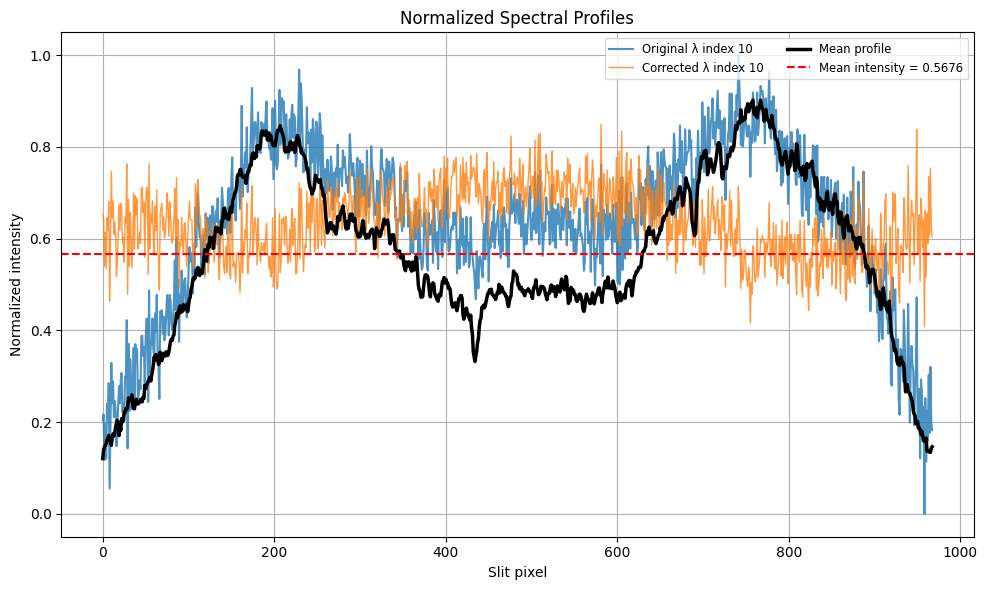

In [11]:
norm_profiles, mean_normalized, mean_intensity, minmax_list = correct_spectra_profile(
    data, track_index=0
)

corrected_norm_profiles = correct_profiles_to_mean_intensity(
    norm_profiles, mean_intensity, mean_profile=mean_normalized
)

# plot_normalized_profiles(
#     norm_profiles, mean_profile=mean_normalized, mean_intensity=mean_intensity
# )

plot_normalized_profiles(
    norm_profiles,
    mean_profile=mean_normalized,
    mean_intensity=mean_intensity,
    wavelength_index=10,
    corrected_profiles=corrected_norm_profiles,
)

In [12]:
def denormalize_profiles(
    corrected_profiles, minmax_list
):  # first row is spatial pixels, the second are wavelenghts
    import numpy as np

    denormalized = []

    for profile, (min_val, max_val) in zip(corrected_profiles, minmax_list):
        original = profile * (max_val - min_val) + min_val
        denormalized.append(original)

    return np.array(denormalized)

In [13]:
denormalized_profiles = denormalize_profiles(corrected_norm_profiles, minmax_list)

In [14]:
def plot_denormalized_profile(profile, title="Denormalized Spectral Profile"):
    import matplotlib.pyplot as plt
    import numpy as np

    pixels = np.arange(len(profile))

    plt.figure(figsize=(10, 4))
    plt.plot(pixels, profile, color="green", linewidth=1.5)
    plt.xlabel("Slit pixel")
    plt.ylabel("Original intensity")
    plt.title(title)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

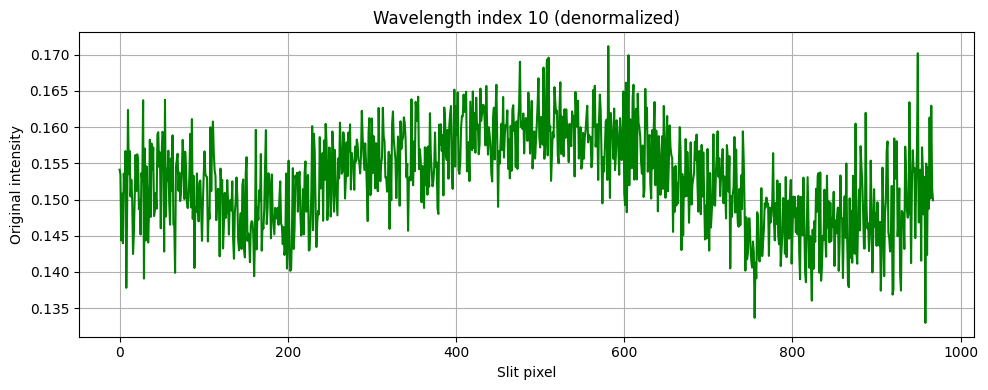

In [15]:
plot_denormalized_profile(
    denormalized_profiles[10], title="Wavelength index 10 (denormalized)"
)

In [16]:
# check if its looks ok
wvl_nm = ilf.wvl_index_to_nm(
    wvl_index=10 + wvl_start, band_2_wavelength=band_2_wavelength
)
print(f"wvl_nm = {wvl_nm}")

wvl_nm = 518


In [17]:
# try to generalize the example


def calc_corrected_data(data):

    corrected_data = data.copy()  # (n_tracks, n_slit_pixels, n_wavelengths)

    # Loop over all track indices
    for track_idx in range(data.shape[0]):
        # Process the current track with your normalization function
        norm_profiles, mean_normalized, mean_intensity, minmax_list = (
            correct_spectra_profile(data, track_index=track_idx)
        )
        corrected_norm_profiles = correct_profiles_to_mean_intensity(
            norm_profiles, mean_intensity, mean_profile=mean_normalized
        )

        denormalized_profiles = denormalize_profiles(
            corrected_norm_profiles, minmax_list
        )
        corrected_data[track_idx, :, :] = denormalized_profiles.T

    return corrected_data

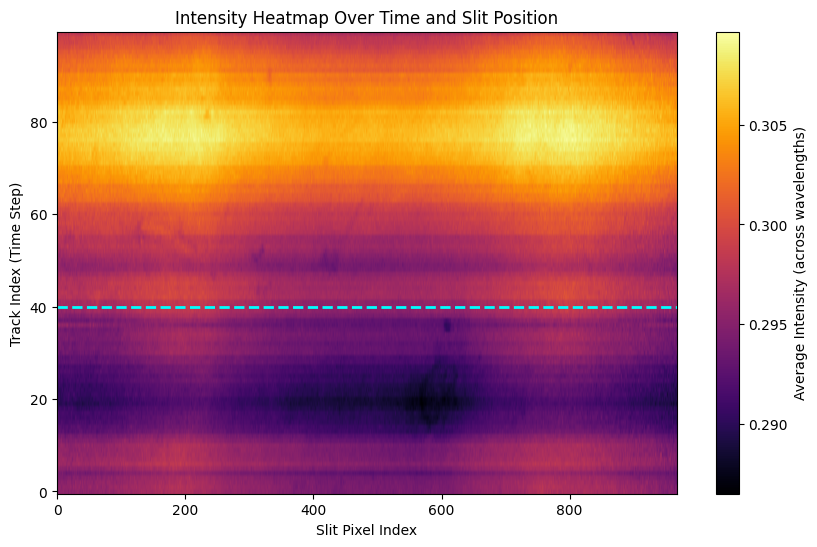

In [18]:
corrected_data = calc_corrected_data(data)
ilf.plot_intensity_heatmap(corrected_data, temporal_index=track_index)

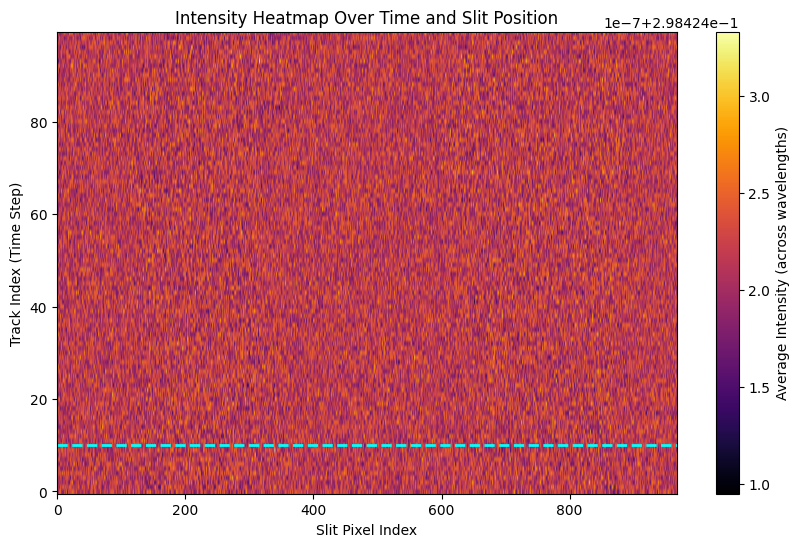

In [19]:
import numpy as np


def correct_transect(data):
    """
    Corrects the entire transect by scaling each pixel's spectral profile
    according to the local mean intensity compared to the global mean.

    Parameters:
      data : np.ndarray
          The input data array of shape (tracks, slit_pixels, wavelengths).

    Returns:
      corrected_data : np.ndarray
          The corrected data array of the same shape as input.
      heat_map : np.ndarray
          The mean intensity for each pixel (tracks, slit_pixels).
      correction_factor : np.ndarray
          The scaling factor applied to each pixel.
      global_mean : float
          The global average intensity computed from the heat map.
    """
    # 1. Compute the heat map: mean intensity over wavelengths.
    heat_map = np.mean(data, axis=2)  # shape: (tracks, slit_pixels)

    # 2. Compute the global mean intensity.
    global_mean = np.mean(heat_map)

    # 3. Compute the correction factor for each pixel.
    correction_factor = np.where(heat_map != 0, global_mean / heat_map, 1)

    # 4. Apply the correction factor uniformly across wavelengths.
    correction_factor_expanded = correction_factor[:, :, np.newaxis]
    corrected_data = data * correction_factor_expanded

    return corrected_data, heat_map, correction_factor, global_mean


# Example usage:
corrected_data, heat_map, correction_factor, global_mean = correct_transect(data)

# Now, for example, to visualize the corrected heat map for a given track:
import illumination_functions as ilf

track_index = 10  # choose a track index
ilf.plot_intensity_heatmap(corrected_data, temporal_index=track_index)